TASK 01 

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data (AND gate)
# =========================
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

# =========================
# Perceptron Implementation
# =========================
def train_perceptron(X, y, learning_rate=0.1, max_epochs=100):
    # Initialize weights randomly and bias to zero
    np.random.seed(42)
    weights = np.random.randn(X.shape[1]) * 0.5
    bias = 0.0
    
    # Step activation function
    def step(x):
        return 1 if x >= 0 else 0
    
    epochs_converged = None
    
    for epoch in range(max_epochs):
        errors = 0
        for i in range(len(X)):
            # Forward pass
            linear_output = np.dot(X[i], weights) + bias
            prediction = step(linear_output)
            
            # Update if error exists
            error = y[i] - prediction
            if error != 0:
                weights += learning_rate * error * X[i]
                bias += learning_rate * error
                errors += 1
        
        # Stop if no errors (converged)
        if errors == 0:
            epochs_converged = epoch + 1
            break
    
    return weights, bias, epochs_converged

# =========================
# Train with different learning rates
# =========================
learning_rates = [0.1, 0.01, 0.5]
results = {}

print("=" * 60)
print("PERCEPTRON - AND GATE CLASSIFICATION")
print("=" * 60)

for lr in learning_rates:
    w, b, epochs = train_perceptron(X, y, learning_rate=lr, max_epochs=100)
    results[lr] = {'weights': w, 'bias': b, 'epochs': epochs}
    
    print(f"\n--- Learning Rate: {lr} ---")
    print(f"Weights: [{w[0]:.3f}, {w[1]:.3f}]")
    print(f"Bias: {b:.3f}")
    print(f"Epochs to converge: {epochs if epochs else 'Did not converge'}")

# =========================
# Test trained model
# =========================
def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return (linear >= 0).astype(int)

print("\n" + "=" * 60)
print("FINAL PREDICTIONS (using lr=0.1 model)")
print("=" * 60)

w_best = results[0.1]['weights']
b_best = results[0.1]['bias']

print("\nInput -> Prediction (Expected)")
for i, inp in enumerate(X):
    pred = predict(inp, w_best, b_best)
    print(f"{inp} -> {pred[0]} ({y[i]})")

# =========================
# Decision Boundary Visualization
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, lr in enumerate(learning_rates):
    w = results[lr]['weights']
    b = results[lr]['bias']
    
    # Create meshgrid
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = predict(np.c_[xx.ravel(), yy.ravel()], w, b)
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    axes[idx].scatter(X[y==0][:,0], X[y==0][:,1], color='blue', label='Class 0', s=100, edgecolors='black')
    axes[idx].scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Class 1', s=100, edgecolors='black', marker='s')
    axes[idx].set_xlabel('x1')
    axes[idx].set_ylabel('x2')
    axes[idx].set_title(f'Learning Rate = {lr}\nEpochs: {results[lr]["epochs"]}')
    axes[idx].legend()
    axes[idx].set_xlim(-0.2, 1.2)
    axes[idx].set_ylim(-0.2, 1.2)

plt.suptitle('AND Gate Decision Boundaries with Different Learning Rates', fontsize=14)
plt.tight_layout()
plt.show()

PERCEPTRON - AND GATE CLASSIFICATION

--- Learning Rate: 0.1 ---
Weights: [0.248, 0.131]
Bias: -0.300
Epochs to converge: 6

--- Learning Rate: 0.01 ---
Weights: [0.128, 0.011]
Bias: -0.130
Epochs to converge: 21

--- Learning Rate: 0.5 ---
Weights: [0.748, 0.431]
Bias: -1.000
Epochs to converge: 4

FINAL PREDICTIONS (using lr=0.1 model)

Input -> Prediction (Expected)


IndexError: invalid index to scalar variable.

In [6]:
#task 03
import torch
import torch.nn as nn

# Dummy data
X = torch.randn(5, 4)
y = torch.tensor([0, 1, 2, 1, 0])

# Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MLP()

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(20):
    optimizer.zero_grad()

    outputs = model(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.1555
Epoch 1, Loss: 1.1232
Epoch 2, Loss: 1.0917
Epoch 3, Loss: 1.0606
Epoch 4, Loss: 1.0300
Epoch 5, Loss: 0.9999
Epoch 6, Loss: 0.9709
Epoch 7, Loss: 0.9425
Epoch 8, Loss: 0.9149
Epoch 9, Loss: 0.8877
Epoch 10, Loss: 0.8614
Epoch 11, Loss: 0.8359
Epoch 12, Loss: 0.8117
Epoch 13, Loss: 0.7888
Epoch 14, Loss: 0.7668
Epoch 15, Loss: 0.7454
Epoch 16, Loss: 0.7259
Epoch 17, Loss: 0.7067
Epoch 18, Loss: 0.6880
Epoch 19, Loss: 0.6700


# (Digits Dataset)

Epoch 0: Train=2.0785, Val=1.8279
Epoch 1: Train=1.5346, Val=1.3322
Epoch 2: Train=1.0504, Val=0.9350
Epoch 3: Train=0.7161, Val=0.6842
Epoch 4: Train=0.5109, Val=0.5276
Epoch 5: Train=0.3896, Val=0.4249
Epoch 6: Train=0.3083, Val=0.3502
Epoch 7: Train=0.2513, Val=0.3002
Epoch 8: Train=0.2105, Val=0.2642
Epoch 9: Train=0.1794, Val=0.2360
Epoch 10: Train=0.1580, Val=0.2129
Epoch 11: Train=0.1411, Val=0.1948
Epoch 12: Train=0.1232, Val=0.1792
Epoch 13: Train=0.1122, Val=0.1664
Epoch 14: Train=0.1001, Val=0.1555
Epoch 15: Train=0.0909, Val=0.1464
Epoch 16: Train=0.0838, Val=0.1388
Epoch 17: Train=0.0759, Val=0.1328
Epoch 18: Train=0.0695, Val=0.1272
Epoch 19: Train=0.0643, Val=0.1218
Epoch 20: Train=0.0606, Val=0.1181
Epoch 21: Train=0.0571, Val=0.1143
Epoch 22: Train=0.0513, Val=0.1104
Epoch 23: Train=0.0528, Val=0.1065
Epoch 24: Train=0.0444, Val=0.1041
Epoch 25: Train=0.0414, Val=0.1018
Epoch 26: Train=0.0407, Val=0.0990
Epoch 27: Train=0.0363, Val=0.0977
Epoch 28: Train=0.0337, Val=0.

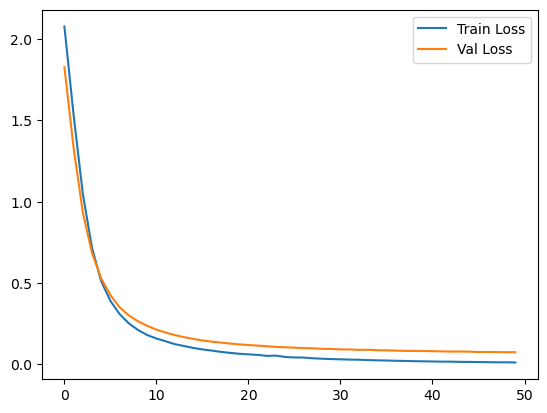

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# =========================
# 1. Load Dataset
# =========================
data = load_digits()
X = data.data
y = data.target

# =========================
# 2. Preprocessing
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# =========================
# 3. Split (70/15/15)
# =========================
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

# =========================
# 4. Model
# =========================
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================
# 5. Training Setup
# =========================
max_epochs = 50
best_loss = float('inf')
patience = 10
counter = 0

train_loss_history = []
val_loss_history = []

# =========================
# 6. Training Loop
# =========================
for epoch in range(max_epochs):

    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_loss_history.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    # Checkpoint
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    # Early Stopping
    if counter >= patience:
        print("Early stopping triggered")
        break

# =========================
# 7. Load Best Model
# =========================
model.load_state_dict(torch.load("best_model.pth"))

# =========================
# 8. Testing
# =========================
model.eval()
test_loss = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

# =========================
# 9. Visualization
# =========================
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.legend()
plt.show()